# How the Giacomini–White test decides whether one forecasting model beats another

### A synthetic walk-through of Hypotheses **1a** and **1b**

---

This notebook does **not** touch real data or the real models. It builds a small artificial world where **we already know the right answer**, runs two toy forecasting models on it, and then applies exactly the test the thesis pre-registers — Giacomini–White with HAC standard errors — to see whether the test recovers the answer we planted.

That is the whole point. On real data you never know whether a test that says *"significant"* is telling the truth. On synthetic data you do, so you can check that the machinery works before you trust it.

### The two hypotheses being illustrated

| | Claim | Question in one sentence |
|---|---|---|
| **H1a** | HR-ETE-GNN has strictly lower expected loss than H-ETE-GNN | *Is the Rényi model better on average?* |
| **H1b** | That advantage is concentrated in turbulent (Hurst < 0.5) regimes | *Is it better **specifically when the market is turbulent**?* |

H1a is the "does it work" question. H1b is the thesis — the entire argument for using a tail-sensitive Rényi order α < 1 is that tails only matter when the market is not behaving normally. A model that is uniformly 1% better everywhere passes H1a and **fails** the story.

### The layman's version of the whole notebook

> Two weather forecasters compete for three years. Each day you write down how badly each one missed, and subtract: **positive = forecaster B won today**. At the end you have a long list of daily score differences.
>
> **H1a asks:** is the average of that list convincingly above zero, or could a run of luck produce it? The hard part is that *"luck"* is not one coin flip per day — storms last a week, so B's good days come in clumps. A test that assumes every day is an independent coin flip will mistake one lucky month for a thousand lucky days and declare victory far too easily. **HAC standard errors** are the fix.
>
> **H1b asks:** do B's wins land on the stormy days? You take the same list of daily differences and regress it on a *stormy-yesterday* flag. If the coefficient on that flag is positive and significant, B is not just better — B is better *for the reason claimed*.

### Contents

| § | What happens |
|---|---|
| 1 | Build the synthetic world: a regime process, 10 fake ETFs, two forecasting models |
| 2 | Turn forecasts into losses and into the daily loss differential `d_t` |
| 3 | **H1a** — the unconditional test, step by step, with every number derived by hand and cross-checked |
| 4 | Why HAC standard errors are not optional (and why pooling the panel would break the test) |
| 5 | **H1b** — the regime-conditional test: the regression, the one-sided coefficient, the joint χ² |
| 6 | Does the test actually work? A Monte-Carlo check of its size and power |
| 7 | Four worlds: no effect, uniform effect, regime-only effect, mixed — and what the results look like in each |
| 8 | Plain-language summary and how to read the real results table |

## §0 — Setup

The test functions are imported from `thesis_stats.py`, the same module the real analysis uses. Nothing is re-implemented here except small by-hand versions used to *show* what the library is doing internally.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy import stats

from thesis_stats import (qlike, newey_west_lrv, diebold_mariano,
                          giacomini_white, min_detectable_effect)

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.labelsize": 9.5, "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "legend.fontsize": 8.5, "legend.frameon": False, "font.size": 9.5,
})

C_BASE = "#9AA0A6"   # Model A  -- stands in for H-ETE-GNN   (Shannon)
C_NEW  = "#1F6FEB"   # Model B  -- stands in for HR-ETE-GNN  (Renyi)
C_TRUE = "#202124"   # realised volatility
C_TURB = "#E8833A"   # turbulent regime
C_POS  = "#2E7D5B"
C_NEG  = "#C0392B"

RNG_MASTER = 20260908
print("numpy", np.__version__, "| pandas", pd.__version__, "| ready")

numpy 2.5.2 | pandas 3.0.5 | ready


## §1 — A synthetic world with a known answer

Everything here is invented, but each piece mirrors one piece of the real setup.

| Synthetic piece | Real counterpart |
|---|---|
| Two-state Markov chain `s_t` ∈ {calm, turbulent} | Actual market regimes (2008, 2020, 2022) |
| Noisy observed `H_t` around 0.57 (calm) / 0.44 (turbulent) | The rolling Hurst exponent estimate |
| `Turbulent_{t−1} = 1{H_{t−1} < 0.5}` | The lagged Hurst regime instrument of H1b |
| 10 correlated volatility series | The 10 country ETFs |
| **Model A** — a fixed-memory EWMA forecast, plus its own noise | H-ETE-GNN (Shannon graph) |
| **Model B** — the same forecast nudged toward the truth by `w`, plus its own noise | HR-ETE-GNN (Rényi graph) |

**The one knob that matters.** Ignoring noise for a moment, Model B is

$$\widehat{RV}^{B}_t \;=\; \widehat{RV}^{A}_t \;+\; w_t\,\bigl(\text{oracle}_t - \widehat{RV}^{A}_t\bigr),
\qquad w_t=\begin{cases} w_{\text{calm}} & \text{calm day}\\ w_{\text{turb}} & \text{turbulent day}\end{cases}$$

`w` is the fraction of the distance to the best possible forecast that B closes. Setting `w_calm` small and `w_turb` large plants exactly the effect H1b is designed to find: **B is barely better in calm markets and clearly better in turbulence.** Because we choose `w`, we know the ground truth, and every p-value later in the notebook can be graded against it.

**Each model also gets its own independent estimation noise** — a persistent multiplicative wobble of the same size for both. This matters more than it looks:

- Without it, `w = 0` would make the two models *byte-identical*, `d_t` would be exactly zero every day, and the null hypothesis would be untestable rather than merely true. With it, `w = 0` gives two genuinely **different** models that are nonetheless **equally good in expectation** — which is precisely what H₀ asserts, and what §6 needs in order to check the test's false-positive rate.
- It is also what real competing models look like: two architectures make different mistakes on different days even when neither is better.

Two further imperfections keep the exercise honest:

1. The regime indicator uses the **lagged, noisy** Hurst estimate, not the true state — so on some days it is simply wrong, exactly as in the real data.
2. The 10 series are **cross-sectionally correlated** (a common shock plus idiosyncratic noise) — which is what makes §4's warning about pooling matter.

In [2]:
N_ETF = 10

def simulate_world(T=1000, w_calm=0.010, w_turb=0.180, seed=0, burn=250,
                   sig_m=0.16, rho_m=0.5, h_noise=0.065):
    """One synthetic out-of-sample period: regimes, 10 RV series, two models.

    w_calm / w_turb : how far each model closes the gap to the perfect forecast,
                      by regime. Equal values -> a uniform advantage; w = 0 for
                      both -> the null hypothesis is exactly true.
    sig_m, rho_m    : size and persistence of each model's OWN estimation noise.
                      Drawn independently for A and B but from the same
                      distribution, so it shifts neither model's expected loss.
                      Within a model it is largely COMMON across the 10 ETFs --
                      one network makes one mistake on all its nodes at once.

    Returns a dict with the realised RV, both models' forecasts (T x N_ETF),
    the true regime state and the *observable* lagged Hurst instrument.
    """
    rng = np.random.default_rng(seed)
    n = T + burn

    # --- 1. latent regime: persistent two-state Markov chain -----------------
    stay = {0: 0.982, 1: 0.950}                 # calm spells ~55d, turbulent ~20d
    s = np.zeros(n, dtype=int)
    for t in range(1, n):
        s[t] = s[t - 1] if rng.random() < stay[s[t - 1]] else 1 - s[t - 1]

    # --- 2. observable (noisy, imperfect) Hurst estimate ---------------------
    H = 0.57 - 0.13 * s + rng.normal(0, h_noise, n)

    # --- 3. true realised volatility: common factor + idiosyncratic, AR(1) ---
    common = rng.normal(0, 1, n)
    idio   = rng.normal(0, 1, (n, N_ETF))
    z = 0.75 * common[:, None] + 0.66 * idio    # correlated across the 10 series
    x = np.zeros((n, N_ETF))
    rho, sig_e = 0.85, 0.33
    for t in range(1, n):
        x[t] = rho * x[t - 1] + sig_e * z[t]
    mu = np.log(0.90 + 0.85 * s)                # regime shifts the *level* of vol
    rv = np.exp(mu[:, None] + x)                # daily volatility in %

    # --- 4. the common starting point: a fixed-memory EWMA forecast ----------
    lam = 0.94
    var_a = np.zeros((n, N_ETF)); var_a[0] = rv[0] ** 2
    for t in range(1, n):
        var_a[t] = lam * var_a[t - 1] + (1 - lam) * rv[t - 1] ** 2
    base = np.sqrt(var_a)                       # forecast of day t, uses data to t-1

    # --- 5. the oracle: the best feasible forecast given the regime ----------
    oracle = np.exp(mu[:, None] + rho * np.r_[x[:1], x[:-1]] + 0.5 * sig_e ** 2)

    # --- 6. each model's own persistent estimation noise (same law for both) --
    #     0.8 * a model-wide shock + 0.6 * per-ETF shock, then AR(1) in time
    model_shock = rng.normal(0, 1, (n, 2))
    eps = 0.8 * np.repeat(model_shock, N_ETF, axis=1) + 0.6 * rng.normal(0, 1, (n, 2 * N_ETF))
    u = np.zeros((n, 2 * N_ETF))
    for t in range(1, n):
        u[t] = rho_m * u[t - 1] + np.sqrt(1 - rho_m ** 2) * eps[t]
    noise_a, noise_b = np.exp(sig_m * u[:, :N_ETF]), np.exp(sig_m * u[:, N_ETF:])

    # --- 7. the two competing forecasts --------------------------------------
    w = np.where(s == 1, w_turb, w_calm)[:, None]
    pred_a = base * noise_a
    pred_b = (base + w * (oracle - base)) * noise_b

    sl = slice(burn, n)
    turb_lag = (np.r_[H[0], H[:-1]] < 0.50).astype(float)   # instrument: known at t-1
    return {
        "rv": rv[sl], "pred_a": pred_a[sl], "pred_b": pred_b[sl],
        "state": s[sl], "hurst": H[sl], "turb_lag": turb_lag[sl],
        "T": T, "w_calm": w_calm, "w_turb": w_turb, "seed": seed,
    }


W = simulate_world(T=1000, w_calm=0.010, w_turb=0.180, seed=RNG_MASTER)
T = W["T"]

print(f"Test days T                      : {T}")
print(f"Days in turbulent regime (true)  : {int(W['state'].sum())}")
print(f"Days flagged Turbulent_(t-1) = 1 : {int(W['turb_lag'].sum())}")
print(f"Instrument agrees with true state: "
      f"{100 * np.mean(W['turb_lag'] == np.r_[W['state'][0], W['state'][:-1]]):.1f}%")
print(f"Mean RV  calm / turbulent        : {W['rv'][W['state']==0].mean():.3f}"
      f" / {W['rv'][W['state']==1].mean():.3f}")

Test days T                      : 1000
Days in turbulent regime (true)  : 226
Days flagged Turbulent_(t-1) = 1 : 294
Instrument agrees with true state: 84.9%
Mean RV  calm / turbulent        : 1.213 / 2.009


### What the world looks like

The top panel is one of the ten synthetic ETFs. Shaded bands are the true turbulent regimes, and Model B is the one that tracks the truth slightly better inside them.

**The honest observation is that you cannot see it.** The two forecast lines sit almost on top of each other, and both wander around a realised-volatility series far noisier than either. An effect that is worth a real improvement in average loss is simply not visible at this resolution — which is the entire reason the rest of the notebook exists. Eyeballing forecast plots is how people convince themselves of improvements that are not there, and fail to notice ones that are.

The bottom panel is the observed Hurst estimate with the 0.5 cut. This is the *only* regime information the test is allowed to use, and it is visibly noisy: it dips below 0.5 on some calm days and stays above on some turbulent ones.

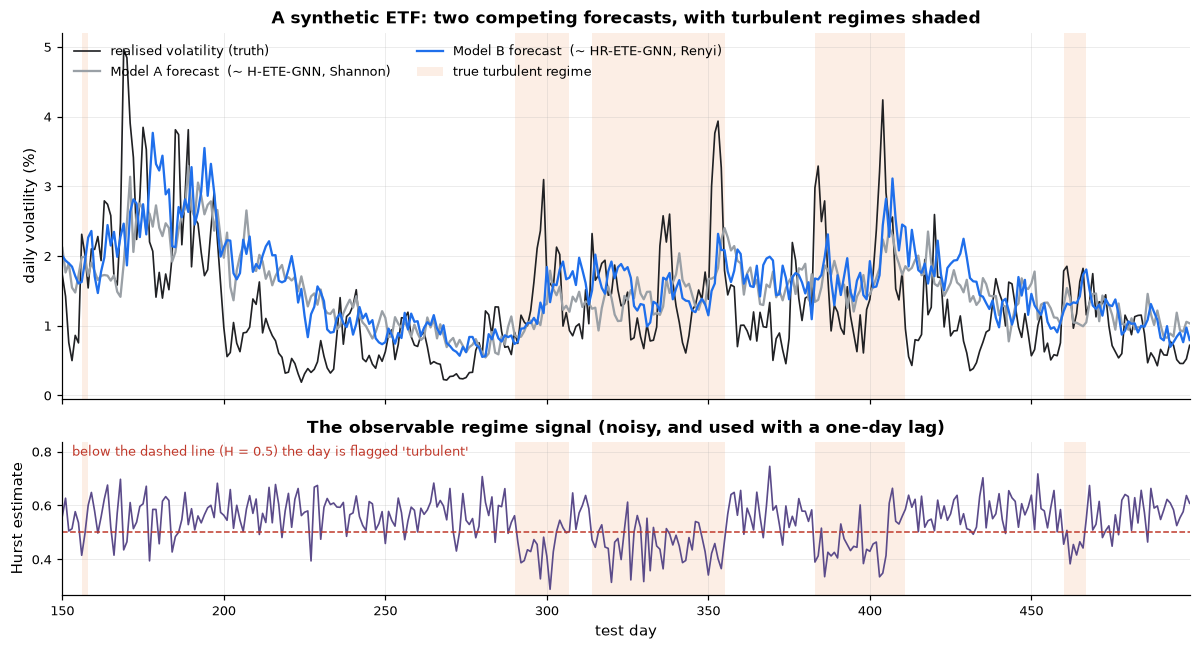

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6.0), sharex=True,
                         gridspec_kw={"height_ratios": [2.4, 1]})
win = slice(150, 500)                      # a readable slice of the sample
t = np.arange(T)[win]
k = 0                                      # show ETF #1

def shade(ax, state, color=C_TURB, alpha=0.13):
    dd = np.diff(np.r_[0, np.asarray(state, int), 0])
    for a, b in zip(np.where(dd == 1)[0], np.where(dd == -1)[0]):
        ax.axvspan(a, b, color=color, alpha=alpha, lw=0)

ax = axes[0]
shade(ax, W["state"])
ax.plot(t, W["rv"][win, k],     color=C_TRUE, lw=1.1, label="realised volatility (truth)")
ax.plot(t, W["pred_a"][win, k], color=C_BASE, lw=1.5, label="Model A forecast  (~ H-ETE-GNN, Shannon)")
ax.plot(t, W["pred_b"][win, k], color=C_NEW,  lw=1.5, label="Model B forecast  (~ HR-ETE-GNN, Renyi)")
ax.set_ylabel("daily volatility (%)")
ax.set_title("A synthetic ETF: two competing forecasts, with turbulent regimes shaded")
h, l = ax.get_legend_handles_labels()
ax.legend(h + [Patch(facecolor=C_TURB, alpha=0.13)], l + ["true turbulent regime"],
          ncol=2, loc="upper left")
ax.set_xlim(t[0], t[-1])

ax = axes[1]
shade(ax, W["state"])
ax.plot(t, W["hurst"][win], color="#5B4B8A", lw=1.1)
ax.axhline(0.5, color=C_NEG, lw=1.0, ls="--")
ax.set_ylim(W["hurst"][win].min() - 0.02, W["hurst"][win].max() + 0.09)
ax.text(t[3], ax.get_ylim()[1] - 0.01,
        "below the dashed line (H = 0.5) the day is flagged 'turbulent'",
        color=C_NEG, fontsize=8.5, va="top")
ax.set_ylabel("Hurst estimate")
ax.set_xlabel("test day")
ax.set_title("The observable regime signal (noisy, and used with a one-day lag)")
plt.tight_layout(); plt.show()

## §2 — From forecasts to the one series the test actually sees

Every hypothesis in RQ1 is a statement about a **single number per day**: `d_t`, the loss differential.

**Step 1 — score each model each day, per ETF.** The pre-registered primary loss is **QLIKE**, which is robust to the fact that realised volatility is itself a noisy estimate of true volatility (Patton, 2011). Lower is better.

**Step 2 — average across the ten ETFs *first*, then difference.**

$$d_t \;=\; \underbrace{\tfrac{1}{10}\sum_{i=1}^{10} L_t\bigl(\text{Model A},i\bigr)}_{\text{how badly A missed on day }t} \;-\; \underbrace{\tfrac{1}{10}\sum_{i=1}^{10} L_t\bigl(\text{Model B},i\bigr)}_{\text{how badly B missed on day }t}$$

so **`d_t > 0` means Model B won day `t`**. Averaging across ETFs before the test — rather than pooling all 10 × T observations — is the choice flagged as *Issue #9* in the hypotheses document; §4 shows numerically why it matters.

Whatever happens from here on, the test never sees the models again. It sees `d_t`, a series of T numbers, and the regime flag.

In [4]:
def loss_differential(world, loss=qlike):
    """Per-day cross-sectional mean loss for each model, and d_t = L_A - L_B."""
    LA = loss(world["rv"], world["pred_a"], warn=False)   # (T, N_ETF)
    LB = loss(world["rv"], world["pred_b"], warn=False)
    la, lb = LA.mean(axis=1), LB.mean(axis=1)             # average the 10 ETFs first
    return la, lb, la - lb, LA, LB

l_a, l_b, d, LA, LB = loss_differential(W)

summary = pd.DataFrame({
    "mean QLIKE": [l_a.mean(), l_b.mean()],
    "  on calm days":      [l_a[W["state"] == 0].mean(), l_b[W["state"] == 0].mean()],
    "  on turbulent days": [l_a[W["state"] == 1].mean(), l_b[W["state"] == 1].mean()],
}, index=["Model A (baseline)", "Model B (candidate)"])
display(summary)

print(f"\nmean d_t (d-bar)          : {d.mean():+.5f}   (positive -> Model B better)")
print(f"relative improvement      : {100 * d.mean() / l_a.mean():.2f}% of baseline loss")
print(f"days Model B won          : {int((d > 0).sum())} of {T}  ({100*(d>0).mean():.1f}%)")
print(f"std dev of d_t            : {d.std(ddof=1):.5f}")

,mean QLIKE,on calm days,on turbulent days
Model A (baseline),0.7175,0.7127,0.7337
Model B (candidate),0.6747,0.7120,0.5471



mean d_t (d-bar)          : +0.04273   (positive -> Model B better)
relative improvement      : 5.96% of baseline loss
days Model B won          : 542 of 1000  (54.2%)
std dev of d_t            : 0.40920


### The single most useful diagnostic plot: the running total of `d_t`

The cumulative sum of the daily differences answers the question a panelist will actually ask out loud: *"is this a steady edge, or one good month?"* A staircase that climbs through the whole sample is a real, repeated advantage. A flat line with one cliff is a single lucky episode wearing a small p-value.

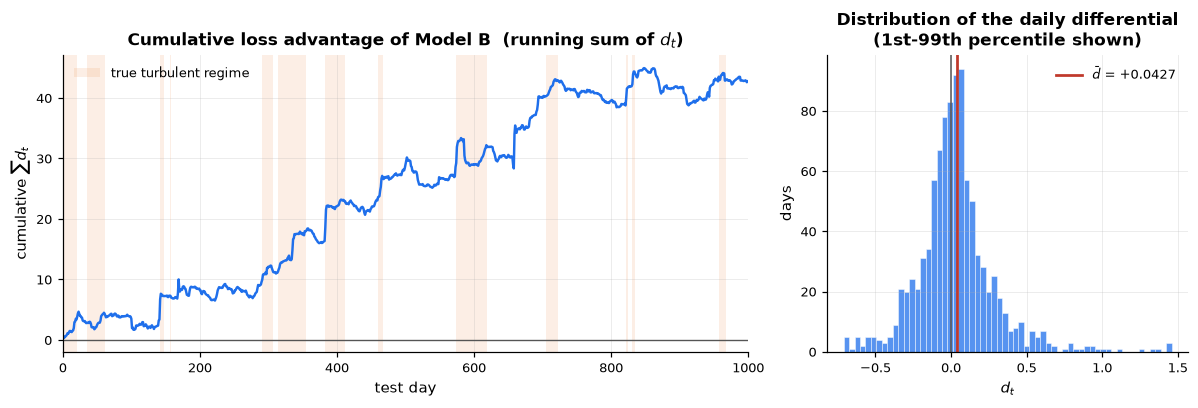

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8),
                         gridspec_kw={"width_ratios": [1.9, 1]})

ax = axes[0]
shade(ax, W["state"])
ax.plot(np.cumsum(d), color=C_NEW, lw=1.6)
ax.axhline(0, color="#555", lw=0.9)
ax.set_title("Cumulative loss advantage of Model B  (running sum of $d_t$)")
ax.set_xlabel("test day"); ax.set_ylabel("cumulative $\\sum d_t$")
ax.legend([Patch(facecolor=C_TURB, alpha=0.13)], ["true turbulent regime"], loc="upper left")
ax.set_xlim(0, T)

ax = axes[1]
lo, hi = np.percentile(d, [1, 99])           # 2% of days fall outside this range
ax.hist(d[(d >= lo) & (d <= hi)], bins=np.linspace(lo, hi, 61), color=C_NEW,
        alpha=0.75, edgecolor="white", lw=0.4)
ax.axvline(0, color="#555", lw=1.0)
ax.axvline(d.mean(), color=C_NEG, lw=1.8, label=f"$\\bar d$ = {d.mean():+.4f}")
ax.set_title("Distribution of the daily differential\n(1st-99th percentile shown)")
ax.set_xlabel("$d_t$"); ax.set_ylabel("days"); ax.legend()
plt.tight_layout(); plt.show()

Two things to read off this figure, both of which recur in the real results:

- The staircase rises **mostly inside the shaded bands**. That is H1b visible to the naked eye — and the reason the unconditional test in §3 is not the interesting one.
- The histogram is centred *barely* to the right of zero and is fat-tailed. Model B loses on plenty of individual days. **A model can be reliably better on average while losing a large share of individual days** — which is precisely why an eyeball test is not enough and a formal test is needed.

## §3 — H1a: is the average advantage real?

> **H₀:** `E[d_t] = 0` — the two models have equal expected accuracy; the observed `d̄ > 0` is sampling noise.
> **H₁:** `E[d_t] > 0` — Model B has strictly lower expected loss. *(one-sided)*

The logic in one breath: **`d̄` is big enough to believe only relative to how much it wobbles.** So compute `d̄`, compute how much a sample average of this series wobbles by chance, take the ratio, and look up how extreme that ratio is.

### The five steps, done by hand

| Step | Quantity | What it is |
|---|---|---|
| 1 | `d̄ = (1/T) Σ d_t` | the mean advantage, in loss units |
| 2 | `σ̂²_HAC` | the **long-run** variance of `d_t` — variance corrected for the fact that today's `d_t` resembles yesterday's |
| 3 | `SE(d̄) = σ̂_HAC / √T` | how far `d̄` typically lands from the truth |
| 4 | `t = d̄ / SE(d̄)` | the advantage measured in standard errors |
| 5 | `p = 1 − Φ(t)` | probability of a `t` this large if H₀ were true |

Step 2 is the only non-obvious one, and it is where a naive test goes wrong; §4 is devoted to it. The Newey–West bandwidth is fixed in advance by the standard rule `⌊4(T/100)^(2/9)⌋`, not chosen after seeing the answer.

In [6]:
# ---- H1a computed from first principles ---------------------------------
T_ = d.size
dbar = d.mean()

L = int(np.floor(4.0 * (T_ / 100.0) ** (2.0 / 9.0)))       # Newey-West bandwidth
e = d - dbar
gamma = [float(e @ e) / T_] + [float(e[j:] @ e[:-j]) / T_ for j in range(1, L + 1)]
lrv_hac = gamma[0] + 2.0 * sum((1 - j / (L + 1)) * gamma[j] for j in range(1, L + 1))

se_hac  = np.sqrt(lrv_hac / T_)
t_hac   = dbar / se_hac
p_hac   = 1 - stats.norm.cdf(t_hac)
lo95    = dbar - 1.645 * se_hac                             # one-sided lower bound
t_naive = dbar / (d.std(ddof=1) / np.sqrt(T_))

# ---- cross-check against thesis_stats -----------------------------------
gw0 = giacomini_white(l_a, l_b)                                    # unconditional GW
dm  = diebold_mariano(l_a, l_b, alternative="greater", lag=L)      # DM, same HAC bandwidth
dm0 = diebold_mariano(l_a, l_b, alternative="greater")             # DM, textbook h-1 = 0 lags

h1a = pd.DataFrame({
    "Quantity": ["Test days T", "Mean loss differential  d-bar",
                 "Relative improvement", "Newey-West bandwidth L",
                 "HAC standard error  SE(d-bar)", "GW statistic  t",
                 "One-sided p-value", "95% one-sided lower bound",
                 "Decision at 5%", "DM (HLN-corrected, same bandwidth)  DM*",
                 "DM one-sided p"],
    "Value": [f"{T_:,}", f"{dbar:+.5f}", f"{100*dbar/l_a.mean():.2f}%", f"{L}",
              f"{se_hac:.5f}", f"{t_hac:.3f}", f"{p_hac:.4f}", f"{lo95:+.5f}",
              "REJECT H0" if p_hac < 0.05 else "fail to reject H0",
              f"{dm['stat']:.3f}", f"{dm['p_value']:.4f}"],
})
display(h1a.style.hide(axis="index"))

print(f"\nby-hand t          : {t_hac:.6f}")
print(f"library chi2 stat  : {gw0['stat']:.6f}   (= t^2 = {t_hac**2:.6f}, 1 df)")
print(f"library const coef : {gw0['coef']['const']:+.6f}   (= d-bar = {dbar:+.6f})")
print("-> the by-hand computation and thesis_stats.giacomini_white agree.")
print(f"\nDM run the textbook way (h-1 = 0 HAC lags): DM* = {dm0['stat']:.3f}, "
      f"p = {dm0['p_value']:.4f}  <- see section 4.1")

Quantity,Value
Test days T,"1,000"
Mean loss differential d-bar,+0.04273
Relative improvement,5.96%
Newey-West bandwidth L,6
HAC standard error SE(d-bar),0.01613
GW statistic t,2.649
One-sided p-value,0.0040
95% one-sided lower bound,+0.01619
Decision at 5%,REJECT H0
"DM (HLN-corrected, same bandwidth) DM*",2.647



by-hand t          : 2.648687
library chi2 stat  : 7.015541   (= t^2 = 7.015541, 1 df)
library const coef : +0.042730   (= d-bar = +0.042730)
-> the by-hand computation and thesis_stats.giacomini_white agree.

DM run the textbook way (h-1 = 0 HAC lags): DM* = 3.302, p = 0.0005  <- see section 4.1


**A note on the χ² vs the t form.** `giacomini_white()` returns a Wald χ² statistic. With no instrument that statistic is exactly `t²`, and χ²(1) is a **two-sided** test: it fires just as happily when Model B is *worse*. H1a is directional, so the number reported is the **one-sided t** above, and the χ² form is reserved for H1b's joint test in §5. This is the distinction the hypotheses document makes in its *"Note on the conditional form."*

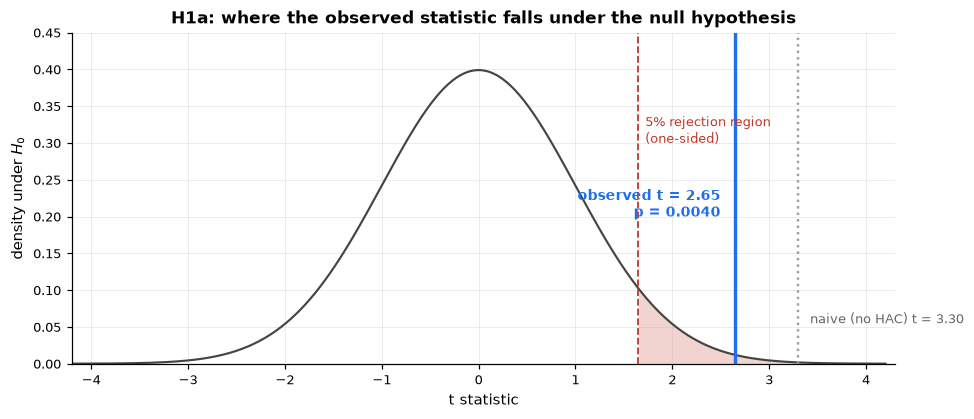

In [7]:
fig, ax = plt.subplots(figsize=(9, 3.9))

grid = np.linspace(-4.2, 4.2, 700)
ax.plot(grid, stats.norm.pdf(grid), color="#444", lw=1.4)
ax.fill_between(grid, 0, stats.norm.pdf(grid), where=grid >= 1.645,
                color=C_NEG, alpha=0.22, lw=0)
ax.axvline(1.645, color=C_NEG, lw=1.2, ls="--")
ax.text(1.72, 0.30, "5% rejection region\n(one-sided)", color=C_NEG, fontsize=8.5)

ax.axvline(t_hac, color=C_NEW, lw=2.2)
ax.annotate(f"observed t = {t_hac:.2f}\np = {p_hac:.4f}",
            xy=(t_hac, 0.10), xytext=(t_hac - 0.15, 0.20),
            color=C_NEW, fontsize=9, ha="right", fontweight="bold")

ax.axvline(t_naive, color=C_BASE, lw=1.6, ls=":")
ax.annotate(f"naive (no HAC) t = {t_naive:.2f}", xy=(t_naive, 0.05),
            xytext=(t_naive + 0.12, 0.055), color="#666", fontsize=8.5)

ax.set_title("H1a: where the observed statistic falls under the null hypothesis")
ax.set_xlabel("t statistic"); ax.set_ylabel("density under $H_0$")
ax.set_ylim(0, 0.45); ax.set_xlim(-4.2, max(4.2, t_naive + 1.0))
plt.tight_layout(); plt.show()

**How to read this picture — the layman's version.** The grey bell curve is *"what the t-statistic would look like across many alternate universes in which the two models are genuinely identical."* Almost all of that curve sits between −2 and +2. The 5% of it furthest to the right is shaded: if the models were equal, a `t` landing in there would happen only one time in twenty.

The blue line is where our actual data landed. Its distance into the tail *is* the p-value. That is all a p-value ever is: **the share of "the models are equal" universes that would produce a result at least this favourable to Model B by chance alone.**

The dotted grey line is the same statistic computed the naive way, treating each day as independent. It sits further right — i.e. looks more "significant" — for no reason other than a modelling error. That gap is the subject of the next section.

## §4 — Two ways to fake significance, and how the test avoids them

### 4.1 Serial correlation: why HAC standard errors are mandatory

Volatility clusters, so forecast errors cluster, so `d_t` clusters: a day on which Model B wins is likely to be followed by another. The effective number of *independent* pieces of evidence is therefore far smaller than T.

The naive standard error `sd(d)/√T` assumes T independent observations and is consequently **too small**, which makes `t` **too big**. The Newey–West HAC estimator adds the autocovariances back in, with declining Bartlett weights:

$$\hat\sigma^2_{HAC} \;=\; \gamma_0 \;+\; 2\sum_{j=1}^{L}\Bigl(1-\tfrac{j}{L+1}\Bigr)\gamma_j$$

If `d_t` really were independent, all `γ_j = 0` for `j ≥ 1` and HAC would collapse back to the naive formula — so using HAC costs nothing when it is unnecessary and rescues you when it is not.

**This is not a hypothetical error.** The textbook Diebold–Mariano recipe for a one-step-ahead forecast (`h = 1`) uses `h − 1 = 0` HAC lags — i.e. the naive variance — on the argument that one-step-ahead *forecast errors* of an optimal forecast should be serially uncorrelated. That argument does not survive contact with this problem: the two models are not optimal, and their **loss differential** stays autocorrelated even when the errors themselves are not. So the naive column below is exactly what a by-the-book DM call produces, which is why the thesis fixes the bandwidth explicitly instead of accepting the default.

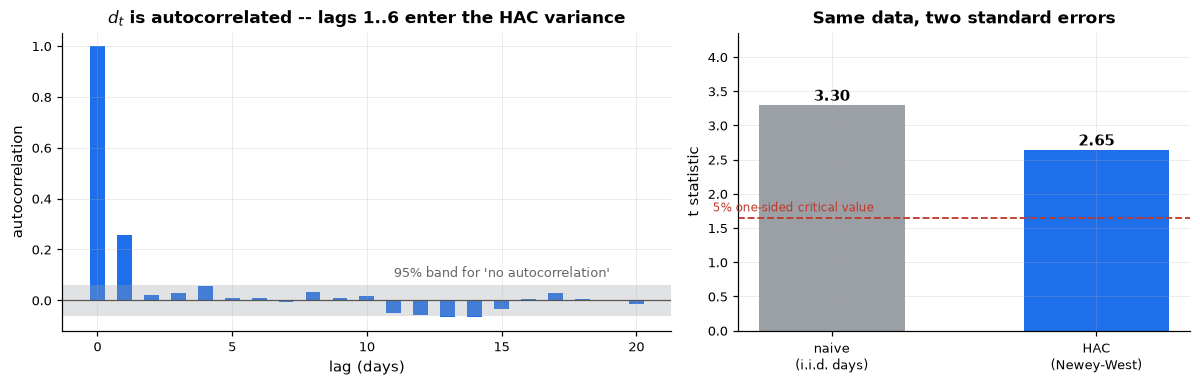

naive SE : 0.01294   ->  t = 3.302
HAC  SE  : 0.01613   ->  t = 2.649
HAC changes the standard error by +24.7%

for comparison, textbook DM at h = 1 (which uses h-1 = 0 HAC lags): 3.302
-> the 'naive' number is not a straw man: it is what the standard DM recipe gives.


In [11]:
def acf(x, nlags=20):
    x = x - x.mean()
    c0 = x @ x
    return np.array([1.0] + [float(x[j:] @ x[:-j]) / c0 for j in range(1, nlags + 1)])

a = acf(d, 20)
ci = 1.96 / np.sqrt(T_)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6),
                         gridspec_kw={"width_ratios": [1.35, 1]})

ax = axes[0]
ax.bar(range(len(a)), a, color=C_NEW, width=0.55)
ax.axhline(0, color="#555", lw=0.8)
ax.axhspan(-ci, ci, color=C_BASE, alpha=0.30, lw=0)
ax.text(11, ci + 0.03, "95% band for 'no autocorrelation'", color="#666", fontsize=8.5)
ax.set_title(f"$d_t$ is autocorrelated -- lags 1..{L} enter the HAC variance")
ax.set_xlabel("lag (days)"); ax.set_ylabel("autocorrelation")

ax = axes[1]
labels = ["naive\n(i.i.d. days)", "HAC\n(Newey-West)"]
vals   = [t_naive, t_hac]
bars = ax.bar(labels, vals, color=[C_BASE, C_NEW], width=0.55)
ax.axhline(1.645, color=C_NEG, ls="--", lw=1.2)
ax.text(-0.45, 1.70, "5% one-sided critical value", color=C_NEG, fontsize=8,
        ha="left", va="bottom")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.06, f"{v:.2f}", ha="center",
            fontsize=9.5, fontweight="bold")
ax.set_title("Same data, two standard errors")
ax.set_ylabel("t statistic"); ax.set_ylim(0, max(vals) * 1.32)
plt.tight_layout(); plt.show()

se_naive = d.std(ddof=1) / np.sqrt(T_)
print(f"naive SE : {se_naive:.5f}   ->  t = {t_naive:.3f}")
print(f"HAC  SE  : {se_hac:.5f}   ->  t = {t_hac:.3f}")
print(f"HAC changes the standard error by {100*(se_hac/se_naive-1):+.1f}%")
print(f"\nfor comparison, textbook DM at h = 1 (which uses h-1 = 0 HAC lags): "
      f"{dm0['stat']:.3f}")
print("-> the 'naive' number is not a straw man: it is what the standard DM recipe gives.")

### 4.2 Pooling the panel: the mistake `d_t` is defined to avoid

The tempting alternative is to throw all 10 ETFs × T days into one long vector of 10T loss differentials — ten times the sample size, therefore a smaller standard error, therefore a bigger `t`. It is also wrong: on any given day the ten ETFs share a common shock, so their ten differentials are **not ten independent observations**. A time-series HAC estimator corrects for correlation *across time*, not *across ETFs on the same date*, so the extra "sample size" is fictitious and the `t` is inflated.

Defining `d_t` as the daily cross-sectional average first removes the problem at the source. Below, the same data is tested both ways.

In [12]:
d_panel = (LA - LB).ravel(order="F")          # all 10 x T differentials, pooled
n_p = d_panel.size
t_pooled = d_panel.mean() / np.sqrt(newey_west_lrv(d_panel) / n_p)

rho_xs = pd.DataFrame(LA - LB).corr().values  # same-day correlation across ETFs
rho_bar = (rho_xs.sum() - np.trace(rho_xs)) / (N_ETF * (N_ETF - 1))

print(f"mean pairwise cross-sectional correlation of the 10 series : {rho_bar:.3f}")
print(f"mean differential, pooled vs daily-average                 : "
      f"{d_panel.mean():+.5f}  vs  {dbar:+.5f}   (identical by construction)")
print(f"t, pooled 10 x T = {n_p:,} observations                     : {t_pooled:.3f}")
print(f"t, daily cross-sectional average (T = {T_:,})               : {t_hac:.3f}")
print(f"\ninflation factor from pooling: x{t_pooled/t_hac:.2f}  <- fictitious extra evidence")

mean pairwise cross-sectional correlation of the 10 series : 0.263
mean differential, pooled vs daily-average                 : +0.04273  vs  +0.04273   (identical by construction)
t, pooled 10 x T = 10,000 observations                     : 4.633
t, daily cross-sectional average (T = 1,000)               : 2.649

inflation factor from pooling: x1.75  <- fictitious extra evidence


The mean loss differential is identical under both routes — only the standard error changes. Pooling does not find a bigger effect; it merely claims more confidence in the same effect than the data supports. This is *Issue #9* in the hypotheses document, and the reason the definition of `d_t` says **"averaged across the ten ETFs on day `t`."**

## §5 — H1b: is the advantage concentrated in turbulence?

This is the hypothesis the thesis actually rests on.

> **H₀:** the lagged Hurst regime flag carries no information about when Model B wins — `β₁ = 0`.
> **H₁:** the advantage is larger after a turbulent signal — `β₁ > 0`. *(one-sided)*

Giacomini–White is a test of **conditional** predictive ability: `E[d_t | information available at t−1] = 0`. Practically, this means regressing the daily differential on anything known yesterday:

$$d_t \;=\; \beta_0 \;+\; \beta_1\,\text{Turbulent}_{t-1} \;+\; \varepsilon_t$$

with HAC standard errors. The two coefficients read directly:

- **`β₀`** — Model B's average advantage **on calm days**.
- **`β₁`** — the **extra** advantage on days following a turbulent signal. `β₀ + β₁` is the turbulent-day advantage.

Why the instrument must be **lagged**: it has to be something a forecaster could genuinely have known before making the forecast. Using today's regime would be conditioning on information that was not available — a subtler version of look-ahead bias.

In [13]:
z = W["turb_lag"]
gw1 = giacomini_white(l_a, l_b, instruments=z)          # GW with the regime instrument

beta  = gw1["coef"];  se_b = gw1["se"];  tstat = gw1["t"]
p_one = pd.Series(stats.norm.sf(tstat.values), index=tstat.index)   # one-sided (greater)
names = {"const": "beta_0  (calm-regime mean differential)",
         "z1":    "beta_1  (extra advantage in turbulence)"}

reg = pd.DataFrame({
    "coefficient": beta.values, "HAC SE": se_b.values,
    "t": tstat.values, "one-sided p": p_one.values,
}, index=[names[i] for i in beta.index])
display(reg)

n_turb = int(z.sum())
mde = min_detectable_effect(n_turb)
h1b = pd.DataFrame({
    "Quantity": ["beta_0  (calm)", "beta_1  (extra in turbulence)", "HAC SE(beta_1)",
                 "t-statistic for beta_1", "One-sided p-value for beta_1",
                 "Turbulent-regime mean differential (beta_0 + beta_1)",
                 "Days flagged turbulent", "Joint GW chi2(2)", "chi2 p-value",
                 "Min. detectable effect in turbulence (80% power)"],
    "Value": [f"{beta['const']:+.5f}", f"{beta['z1']:+.5f}", f"{se_b['z1']:.5f}",
              f"{tstat['z1']:.3f}", f"{p_one['z1']:.4f}",
              f"{beta['const'] + beta['z1']:+.5f}",
              f"{n_turb} of {T_:,}", f"{gw1['stat']:.3f}", f"{gw1['p_value']:.4f}",
              f"{mde['mde_ratio_at_power'] * d[z==1].std(ddof=1):.5f} (loss units)"],
})
display(h1b.style.hide(axis="index"))

print("\n" + ("H1b SUPPORTED: the advantage is significantly larger after a turbulent signal."
              if p_one["z1"] < 0.05 else
              "H1b NOT supported: no significant regime interaction."))
print(f"Ground truth planted in the simulator: w_calm = {W['w_calm']}, "
      f"w_turb = {W['w_turb']}  ->  the effect IS regime-concentrated.")

,coefficient,HAC SE,t,one-sided p
beta_0 (calm-regime mean differential),0.0230,0.0155,1.4865,0.0686
beta_1 (extra advantage in turbulence),0.0671,0.0314,2.1346,0.0164


Quantity,Value
beta_0 (calm),+0.02300
beta_1 (extra in turbulence),+0.06711
HAC SE(beta_1),0.03144
t-statistic for beta_1,2.135
One-sided p-value for beta_1,0.0164
Turbulent-regime mean differential (beta_0 + beta_1),+0.09011
Days flagged turbulent,"294 of 1,000"
Joint GW chi2(2),8.324
chi2 p-value,0.0156
Min. detectable effect in turbulence (80% power),0.06511 (loss units)



H1b SUPPORTED: the advantage is significantly larger after a turbulent signal.
Ground truth planted in the simulator: w_calm = 0.01, w_turb = 0.18  ->  the effect IS regime-concentrated.


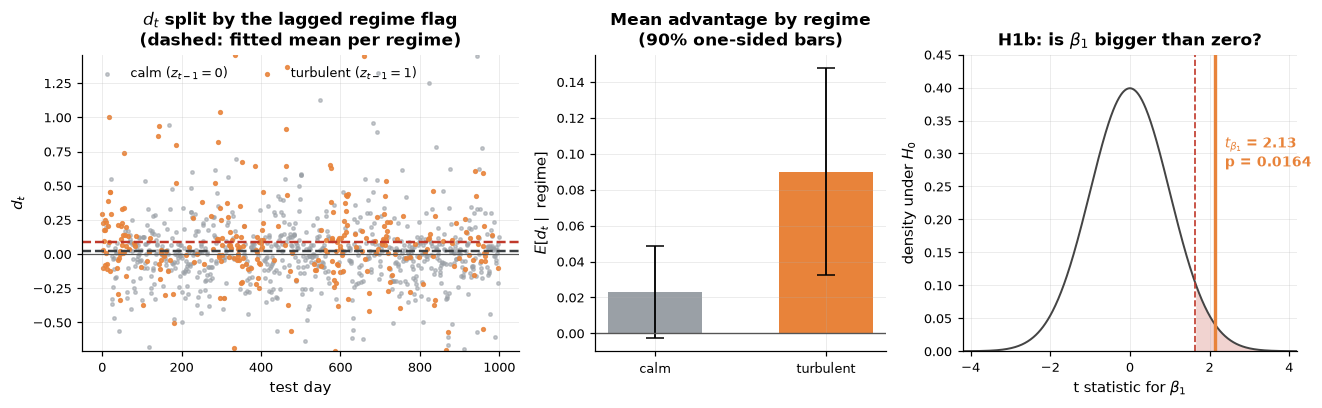

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(12.2, 3.8),
                         gridspec_kw={"width_ratios": [1.5, 1, 1.15]})

# --- (a) d_t through time, coloured by the regime flag --------------------
ax = axes[0]
ax.scatter(np.where(z == 0)[0], d[z == 0], s=5, color=C_BASE, alpha=0.55,
           label="calm ($z_{t-1}=0$)")
ax.scatter(np.where(z == 1)[0], d[z == 1], s=6, color=C_TURB, alpha=0.85,
           label="turbulent ($z_{t-1}=1$)")
ax.axhline(0, color="#555", lw=0.8)
ax.axhline(beta["const"], color="#3C4043", lw=1.6, ls="--")
ax.axhline(beta["const"] + beta["z1"], color=C_NEG, lw=1.6, ls="--")
ax.set_ylim(*np.percentile(d, [1, 99]))
ax.set_title("$d_t$ split by the lagged regime flag\n(dashed: fitted mean per regime)")
ax.set_xlabel("test day"); ax.set_ylabel("$d_t$"); ax.legend(loc="upper left", ncol=2)

# --- (b) the two conditional means with HAC intervals ---------------------
ax = axes[1]
m_calm, m_turb = beta["const"], beta["const"] + beta["z1"]
se_calm = se_b["const"]
se_turb = np.sqrt(se_b["const"]**2 + se_b["z1"]**2)      # illustrative
ax.bar(["calm", "turbulent"], [m_calm, m_turb],
       yerr=[1.645*se_calm, 1.645*se_turb],
       color=[C_BASE, C_TURB], width=0.55, capsize=6, error_kw={"lw": 1.2})
ax.axhline(0, color="#555", lw=0.9)
ax.set_title("Mean advantage by regime\n(90% one-sided bars)")
ax.set_ylabel("$E[d_t \\mid$ regime$]$")

# --- (c) the beta_1 test picture -----------------------------------------
ax = axes[2]
g = np.linspace(-4.2, 4.2, 700)
ax.plot(g, stats.norm.pdf(g), color="#444", lw=1.3)
ax.fill_between(g, 0, stats.norm.pdf(g), where=g >= 1.645, color=C_NEG, alpha=0.22, lw=0)
ax.axvline(1.645, color=C_NEG, ls="--", lw=1.1)
ax.axvline(tstat["z1"], color=C_TURB, lw=2.2)
ax.annotate(f"$t_{{\\beta_1}}$ = {tstat['z1']:.2f}\np = {p_one['z1']:.4f}",
            xy=(tstat["z1"], 0.30), xytext=(tstat["z1"] + 0.25, 0.30), ha="left",
            va="center", color=C_TURB, fontsize=9, fontweight="bold")
ax.set_title("H1b: is $\\beta_1$ bigger than zero?")
ax.set_xlabel("t statistic for $\\beta_1$"); ax.set_ylabel("density under $H_0$")
ax.set_ylim(0, 0.45); ax.set_xlim(-4.2, max(4.2, tstat["z1"] + 1.0))
plt.tight_layout(); plt.show()

Note how much **weaker** the estimated regime effect is than the one planted in the simulator. Model B was given eighteen times the correction on turbulent days (`w_turb = 0.18` vs `w_calm = 0.01`), yet the estimated `β₁` recovers only part of that gap. Three things are eating it:

1. the instrument is the **lagged** flag, and regimes turn over;
2. the Hurst estimate is **noisy**, so some calm days are flagged turbulent and vice-versa — classic attenuation toward zero;
3. turbulent days are a **minority** of the sample, so `β₁` rests on far fewer observations than `β₀`.

All three apply with at least as much force to the real data. This is the concrete reason the hypotheses document insists on reporting the turbulent-day count next to `β₁`: **a null result on H1b is only informative if there were enough turbulent days to detect the effect in the first place.** The minimum-detectable-effect row in the table above is what makes that judgement possible.

## §6 — Does the test actually work? Size and power

A test is only trustworthy if it has two properties, and both can be checked directly here because the true answer is known by construction:

- **Size** — when the two models are equally good (`w = 0`, so H₀ is exactly true), a 5% test must reject about **5%** of the time. More than that and the test manufactures discoveries.
- **Power** — when there really is an effect, how often does the test find it? Low power means a non-significant result is uninformative rather than evidence of no effect.

Note that under `w = 0` the two models are still *different* — each carries its own independent estimation noise, so `d_t` bounces around — they are merely **equally good**. That is exactly the situation H₀ describes, and the hardest one for a test to get right.

The cell below re-runs the entire experiment on many fresh synthetic samples and records the p-values, including what happens if HAC is dropped.

In [15]:
def one_replication(seed, w_calm, w_turb, T=1000):
    w = simulate_world(T=T, w_calm=w_calm, w_turb=w_turb, seed=seed)
    la, lb, dd, _, _ = loss_differential(w)
    t_a  = dd.mean() / np.sqrt(newey_west_lrv(dd) / dd.size)     # H1a, HAC
    t_nv = dd.mean() / (dd.std(ddof=1) / np.sqrt(dd.size))       # H1a, naive SE
    g = giacomini_white(la, lb, instruments=w["turb_lag"])       # H1b, one-sided on z1
    return (stats.norm.sf(t_a), stats.norm.sf(t_nv),
            float(stats.norm.sf(g["t"]["z1"])))

N_REP = 300
scen = {"H0 true  (w = 0 everywhere)":  (0.000, 0.000),
        "effect present (0.010/0.180)": (0.010, 0.180)}

mc = {}
for label, (wc, wt) in scen.items():
    out = np.array([one_replication(10_000 + i, wc, wt) for i in range(N_REP)])
    mc[label] = {"p_h1a": out[:, 0], "p_naive": out[:, 1], "p_h1b": out[:, 2]}
    print(f"{label:<30}  reject H1a @5%: {100*(out[:,0]<0.05).mean():5.1f}%"
          f"   |  reject H1b @5%: {100*(out[:,2]<0.05).mean():5.1f}%"
          f"   |  H1a without HAC: {100*(out[:,1]<0.05).mean():5.1f}%   ({N_REP} reps)")

H0 true  (w = 0 everywhere)     reject H1a @5%:   6.0%   |  reject H1b @5%:   6.7%   |  H1a without HAC:  12.3%   (300 reps)
effect present (0.010/0.180)    reject H1a @5%:  90.3%   |  reject H1b @5%:  73.3%   |  H1a without HAC:  95.7%   (300 reps)


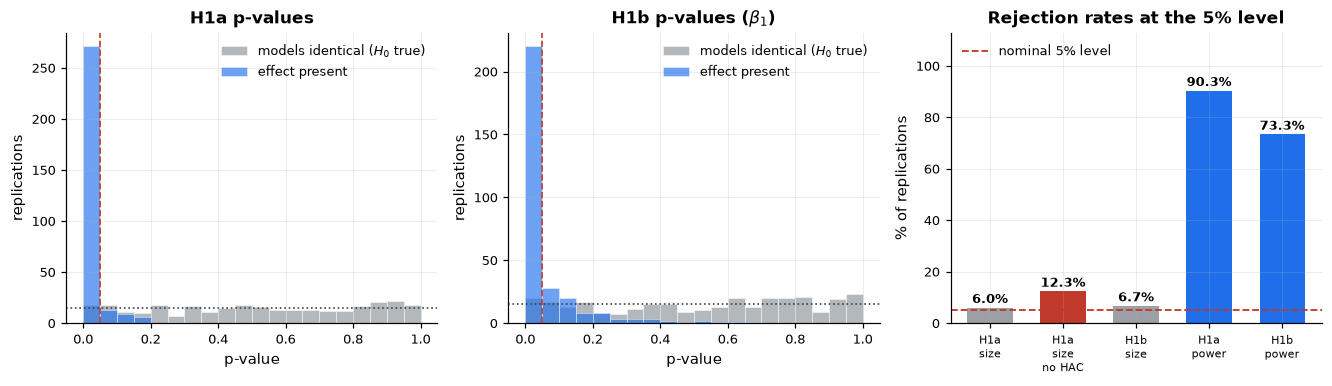

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(12.2, 3.6))
null_lbl, alt_lbl = list(scen.keys())

for ax, key, title in zip(axes[:2], ["p_h1a", "p_h1b"],
                          ["H1a p-values", "H1b p-values ($\\beta_1$)"]):
    ax.hist(mc[null_lbl][key], bins=20, range=(0, 1), color=C_BASE, alpha=0.75,
            edgecolor="white", lw=0.4, label="models identical ($H_0$ true)")
    ax.hist(mc[alt_lbl][key], bins=20, range=(0, 1), color=C_NEW, alpha=0.65,
            edgecolor="white", lw=0.4, label="effect present")
    ax.axhline(N_REP / 20, color="#444", ls=":", lw=1.1)
    ax.axvline(0.05, color=C_NEG, ls="--", lw=1.1)
    ax.set_title(title); ax.set_xlabel("p-value"); ax.set_ylabel("replications")
    ax.legend(loc="upper right")

ax = axes[2]
lbls = ["H1a\nsize", "H1a\nsize\nno HAC", "H1b\nsize", "H1a\npower", "H1b\npower"]
vals = [100*(mc[null_lbl]["p_h1a"] < .05).mean(),
        100*(mc[null_lbl]["p_naive"] < .05).mean(),
        100*(mc[null_lbl]["p_h1b"] < .05).mean(),
        100*(mc[alt_lbl]["p_h1a"] < .05).mean(),
        100*(mc[alt_lbl]["p_h1b"] < .05).mean()]
bars = ax.bar(lbls, vals, color=[C_BASE, C_NEG, C_BASE, C_NEW, C_NEW], width=0.62)
ax.axhline(5, color=C_NEG, ls="--", lw=1.2, label="nominal 5% level")
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v+1.8, f"{v:.1f}%", ha="center", fontsize=8.5,
            fontweight="bold")
ax.set_title("Rejection rates at the 5% level"); ax.set_ylabel("% of replications")
ax.set_ylim(0, max(vals) * 1.25); ax.tick_params(axis="x", labelsize=7.5)
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

**How to read this.** Under H₀ (grey) the p-values are roughly **flat between 0 and 1** — that is what a well-behaved test looks like, and the dotted line marks the expected height. Roughly 5% of them fall left of the red line, which is exactly the false-positive rate promised at the 5% level. If the grey bars piled up near zero, the test would be producing discoveries out of nothing and none of the real results could be trusted.

Under the alternative (blue) the p-values crowd toward zero. The gap between the grey and blue bars is the test's **power**: its ability to notice a real effect.

Three practical consequences for the thesis:

- **HAC is what makes the 5% mean 5%.** The red bar is the same H1a test with the naive standard error, run on data where *the two models are equally good*. It rejects at roughly twice the advertised rate: a "5% test" that is really a 10% test. Every one of those rejections is a claimed discovery that isn't there.
- **H1b has visibly lower power than H1a.** Detecting *"the gain lives in the turbulent subsample"* needs more data than detecting *"there is a gain"*, because it is effectively estimated from the turbulent days alone. A non-significant `β₁` therefore does not license the claim that the regime effect is absent, only that this sample cannot resolve it.
- **Neither test is close to fully powered at this effect size.** With a genuine effect present, H1a still misses it about half the time. That is a statement about the sample size and the noise level, not about the models — and it is the honest reason to report the minimum detectable effect alongside the p-value.

## §7 — Four worlds, four verdicts

The interesting part of the H1a/H1b pair is not either test alone but their **combination**. Below, the same machinery is run on synthetic worlds that differ only in where Model B's advantage was planted.

| World | `w_calm` | `w_turb` | The truth |
|---|---|---|---|
| **A. No effect** | 0.000 | 0.000 | the two models are equally good |
| **B. Uniform gain** | 0.055 | 0.055 | B is better everywhere, equally |
| **C. Regime gain** | 0.000 | 0.200 | B is better *only* in turbulence |
| **D. Main example** | 0.010 | 0.180 | a small calm edge, a large turbulent one |

World **C** is the result the thesis is arguing for. World **B** is the trap: it passes H1a comfortably and would look like a triumph in an abstract, while providing **no support at all** for the tail-sensitivity mechanism that motivates α < 1.

Because a single sample can be lucky in either direction, each world is run **200 times** and the table reports how often each test rejects — a small power study rather than one draw.

In [17]:
worlds = {
    "A. no effect        (0.000 / 0.000)": (0.000, 0.000),
    "B. uniform gain     (0.055 / 0.055)": (0.055, 0.055),
    "C. regime-only gain (0.000 / 0.200)": (0.000, 0.200),
    "D. main example     (0.010 / 0.180)": (0.010, 0.180),
}
N_WORLD_REP = 200

rows = []
for label, (wc, wt) in worlds.items():
    dbar_, b0_, b1_, ta_, tb_, pa_, pb_ = ([] for _ in range(7))
    for i in range(N_WORLD_REP):
        w_ = simulate_world(T=1000, w_calm=wc, w_turb=wt, seed=50_000 + i)
        la_, lb_, d_, _, _ = loss_differential(w_)
        t_a = d_.mean() / np.sqrt(newey_west_lrv(d_) / d_.size)
        g_  = giacomini_white(la_, lb_, instruments=w_["turb_lag"])
        dbar_.append(d_.mean()); b0_.append(g_["coef"]["const"]); b1_.append(g_["coef"]["z1"])
        ta_.append(t_a);         tb_.append(g_["t"]["z1"])
        pa_.append(stats.norm.sf(t_a)); pb_.append(stats.norm.sf(g_["t"]["z1"]))
    rows.append({
        "world": label,
        "mean d-bar": np.mean(dbar_),
        "mean beta_0": np.mean(b0_), "mean beta_1": np.mean(b1_),
        "mean H1a t": np.mean(ta_), "mean H1b t": np.mean(tb_),
        "H1a rejects": 100 * np.mean(np.array(pa_) < 0.05),
        "H1b rejects": 100 * np.mean(np.array(pb_) < 0.05),
    })

res = pd.DataFrame(rows).set_index("world")
res["verdict"] = np.where(
    res["H1b rejects"] > 25,
    np.where(res["H1a rejects"] > 25, "improvement AND mechanism", "mechanism only"),
    np.where(res["H1a rejects"] > 25, "improvement, but NOT the claimed mechanism",
             "nothing detected"))
display(res.style.format({"mean d-bar": "{:+.5f}", "mean beta_0": "{:+.5f}",
                          "mean beta_1": "{:+.5f}", "mean H1a t": "{:.2f}",
                          "mean H1b t": "{:.2f}", "H1a rejects": "{:.1f}%",
                          "H1b rejects": "{:.1f}%"}))

,mean d-bar,mean beta_0,mean beta_1,mean H1a t,mean H1b t,H1a rejects,H1b rejects,verdict
world,,,,,,,,
A. no effect (0.000 / 0.000),-0.00020,+0.00084,-0.00302,0.00,-0.06,5.0%,5.5%,nothing detected
B. uniform gain (0.055 / 0.055),+0.04842,+0.04428,+0.01356,2.46,0.31,78.5%,10.0%,"improvement, but NOT the claimed mechanism"
C. regime-only gain (0.000 / 0.200),+0.06502,+0.03052,+0.10814,2.82,2.49,90.0%,84.0%,improvement AND mechanism
D. main example (0.010 / 0.180),+0.06500,+0.03453,+0.09563,2.90,2.23,91.0%,75.5%,improvement AND mechanism


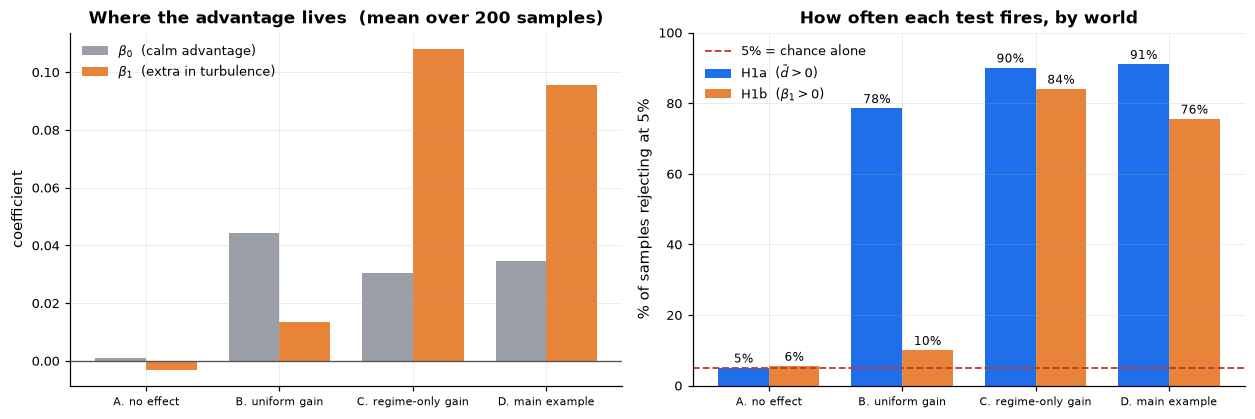

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.9))
lbl = [w.split("(")[0].strip() for w in res.index]
xx = np.arange(len(res))

ax = axes[0]
ax.bar(xx - 0.19, res["mean beta_0"], width=0.38, color=C_BASE,
       label="$\\beta_0$  (calm advantage)")
ax.bar(xx + 0.19, res["mean beta_1"], width=0.38, color=C_TURB,
       label="$\\beta_1$  (extra in turbulence)")
ax.axhline(0, color="#555", lw=0.9)
ax.set_xticks(xx); ax.set_xticklabels(lbl, fontsize=7.5)
ax.set_title(f"Where the advantage lives  (mean over {N_WORLD_REP} samples)")
ax.set_ylabel("coefficient"); ax.legend()

ax = axes[1]
b1 = ax.bar(xx - 0.19, res["H1a rejects"], width=0.38, color=C_NEW,
            label="H1a  ($\\bar d > 0$)")
b2 = ax.bar(xx + 0.19, res["H1b rejects"], width=0.38, color=C_TURB,
            label="H1b  ($\\beta_1 > 0$)")
ax.axhline(5, color=C_NEG, ls="--", lw=1.2, label="5% = chance alone")
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1.5,
                f"{b.get_height():.0f}%", ha="center", fontsize=8)
ax.set_xticks(xx); ax.set_xticklabels(lbl, fontsize=7.5)
ax.set_title("How often each test fires, by world")
ax.set_ylabel("% of samples rejecting at 5%"); ax.set_ylim(0, 100); ax.legend()
plt.tight_layout(); plt.show()

Read the right-hand panel across worlds:

- **World A** — both tests fire at roughly 5%, which is chance alone. Correct: nothing was planted, nothing was found.
- **World B** — H1a fires often, H1b stays at the chance rate. This is the *"model works, story doesn't"* outcome, and the reason H1b has to be pre-registered separately: a uniform improvement would sail through H1a while leaving the tail-sensitivity argument completely unsupported. The honest write-up reports the forecasting gain and says so.
- **World C** — H1b fires. Note what `β₀` does here: the truth is `w_calm = 0`, no calm-market advantage whatsoever, yet the estimated `β₀` comes out clearly positive. Nothing is broken — the regime flag is a noisy lagged proxy, so a share of genuinely turbulent days are labelled calm and carry their advantage into `β₀`. **Misclassification pushes both coefficients toward each other**, which flatters `β₀` and shrinks `β₁`. Read that as a warning: the split between "calm gain" and "turbulence gain" is only as sharp as the regime classifier, and the estimated `β₀` is an upper bound on the true calm-market advantage rather than a measurement of it.
- **World D** — the main example: a small calm edge plus a larger turbulent one. H1a fires more often than H1b, which is the generic pattern — **conditional claims are harder to establish than unconditional ones**, and the gap between the two bars is the price of asking the more interesting question.

Worlds B and C are also a warning about reading `d̄` alone. Both produce a solidly positive `d̄` and both reject H1a most of the time — yet one is a uniform improvement and the other is a crisis-only improvement. **The unconditional number cannot tell them apart. Only the conditional test can.**

## §8 — The whole thing in plain language

**What is being tested.** Two forecasting models produce one number each per day. Each is scored against what actually happened, and the two scores are subtracted. That daily difference, `d_t`, is the entire input to the test.

**H1a — "is Model B better?"** Average the daily differences. Divide by a standard error that accounts for the fact that consecutive days are not independent. If the resulting ratio is above 1.645, fewer than 5% of "the models are equal" worlds would have produced a result this good by luck, and the null is rejected.

**H1b — "is Model B better *when it matters*?"** Take the same daily differences and split them by whether yesterday's Hurst estimate flagged the market as turbulent. The regression `d_t = β₀ + β₁·Turbulent_{t−1} + ε_t` reports the calm-day advantage as `β₀` and the extra turbulent-day advantage as `β₁`. A positive, significant `β₁` says the advantage is concentrated where the theory says it should be.

**Why Giacomini–White rather than plain Diebold–Mariano.** Two reasons, both material here:

1. **It permits conditioning.** DM can only answer "better on average". H1b is a question about *when*, and only a conditional test can answer it.
2. **It survives estimated, nested models.** At α = 1 the Rényi transfer entropy reduces to Shannon, so H-ETE-GNN is a limiting special case of HR-ETE-GNN — the models are nested, and DM's asymptotics assume they are not. GW was built for forecasts from estimated models compared over a **fixed-length rolling estimation window**, which is precisely the setting here. DM is still reported, as the familiar benchmark, with that caveat attached.

**What the test cannot do.** It compares *these two forecast series over this particular sample*. It does not establish that the Rényi graph is better in general, that the improvement will persist out of sample, or that the mechanism is the one claimed — `β₁ > 0` is consistent with the tail-sensitivity story but does not prove it, since anything else that co-moves with turbulence could be the real driver. And a non-significant result is not evidence of equality; §6 shows H1b's power is limited, which is why the turbulent-day count and the minimum detectable effect belong in the results table next to the p-value.

**The three numbers to report, in the order a panelist will ask for them:**

1. `d̄` and the relative improvement — *how much better?* A p-value attached to a 0.3% improvement is statistically detectable and practically uninteresting.
2. The one-sided p-value with its HAC bandwidth — *how sure?*
3. `β₁`, its p-value, and the turbulent-day count — *better for the claimed reason?*

---

### Mapping back to the real analysis

| Notebook object | Real object |
|---|---|
| `simulate_world()` | the actual test-period forecasts from the two trained GNNs |
| `Model A` / `Model B` | H-ETE-GNN (α = 1, Shannon) / HR-ETE-GNN (α < 1, Rényi) |
| `l_a`, `l_b` | daily cross-sectional mean QLIKE of each model over the 10 ETFs |
| `z = turb_lag` | `1{Hurst_{t−1} < 0.5}` from the MSCI World proxy |
| §3 table | the H1a results table |
| §5 table | the H1b results table |
| §6 | the size/power justification for the sample size |

**Two caveats carried over from the hypotheses document.** First, this notebook uses the noisy Hurst flag as the single instrument; *Issue #5* asks for H1b to be run a second time with the explicit crisis-window dummy, and for the two answers to be compared. Second, GW's validity here rests on the retraining protocol using a **fixed-length rolling window** rather than an expanding one — that has to be true of the real training loop, and stated in §3.6, or the test's justification for handling nested models does not apply.